/home/janneke/src/at-gpflow


/tmp/ipykernel_15354/782142137.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_15354/782142137.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
/tmp/ipykernel_15354/782142137.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])
/tmp/ipykernel_15354/782142137.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version

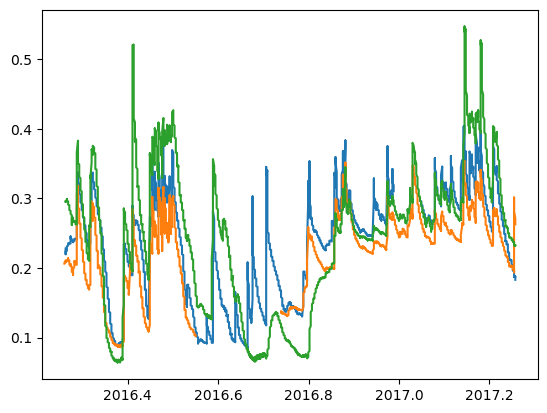

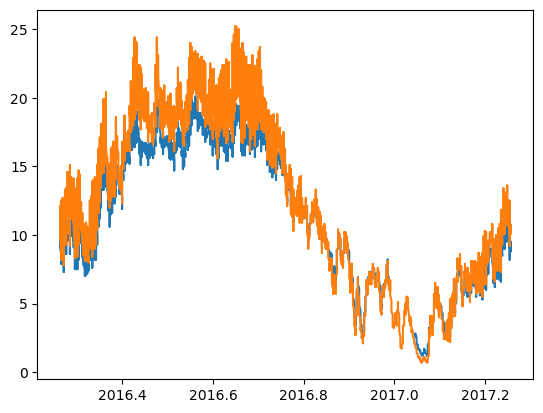

2915 2913


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow"
print(subdir)

sys.path.append(str(subdir))
BASE = os.path.abspath('')

source = pd.read_csv(BASE+"/data/station_data/RM_SM_14_calibrated.csv")
source2 = pd.read_csv(BASE+"/data/station_data/RM_SM_02_calibrated.csv")
target = pd.read_csv(BASE+"/data/station_data/RM_SM_15_calibrated.csv")
source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])

source.index = source["Measurement Time"]
source2.index = source2["Measurement Time"]
target.index = target["Measurement Time"]

source = source.resample("3H").last()
source2 = source2.resample("3H").last()
target = target.resample("3H").last()

source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
source2['decimal_year'] = source2['Measurement Time'].dt.year + (source2['Measurement Time'].dt.dayofyear - 1) / 365.25
target['decimal_year'] = target['Measurement Time'].dt.year + (target['Measurement Time'].dt.dayofyear - 1) / 365.25
source.index = source["decimal_year"]
source2.index = source2["decimal_year"]
target.index = target["decimal_year"]


plt.plot(source.index, source["5 cm VWC [m3/m3]"])
plt.plot(source2.index, source2["5 cm VWC [m3/m3]"])
plt.plot(target.index, target["5 cm VWC [m3/m3]"])
plt.show()
plt.plot(source.index, source["5 cm Temp [oC]"])
plt.plot(target.index, target["5 cm Temp [oC]"])
plt.show()

print(len(source), len(target))

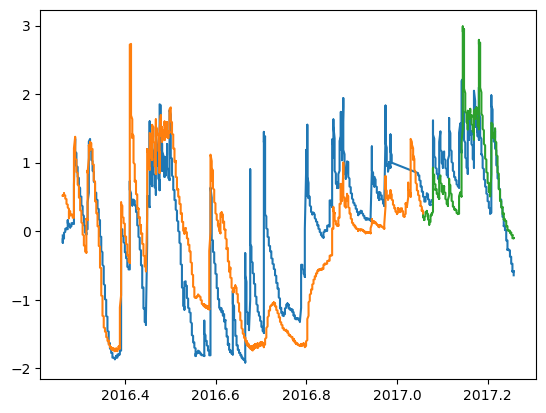

In [2]:
Ax = source.index.to_numpy().reshape(-1, 1)
Bx = target.index.to_numpy().reshape(-1, 1)
Cx = source2.index.to_numpy().reshape(-1, 1)

Ay_nans = source["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
Ay = Ay_nans[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
Ax = Ax[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
By_nans = target["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
By = By_nans[~np.isnan(By_nans)].reshape(-1, 1)
By = (By - By.mean()) / np.std(By)
Bx = Bx[~np.isnan(By_nans)].reshape(-1, 1)

Xtest = Bx[int(len(Bx)*0.8):] 
ytest = By[int(len(By)*0.8):] 
Bx = Bx[:int(len(Bx)*0.8)] 
By = By[:int(len(By)*0.8)] 

Cy_nans = source2["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
Cy = Cy_nans[~np.isnan(Cy_nans)].reshape(-1, 1)
Cy = (Cy - Cy.mean()) / np.std(Cy)
Cx = Cx[~np.isnan(Cy_nans)].reshape(-1, 1)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By)))))
plt.plot(Ax, Ay)
plt.plot(Bx, By)
plt.plot(Xtest, ytest)

[[2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 ...
 [2.01705749e+03 1.00000000e+00]
 [2.01705749e+03 1.00000000e+00]
 [2.01705749e+03 1.00000000e+00]]
[[2016.26283368]
 [2016.28313009]
 [2016.3034265 ]
 [2016.32372292]
 [2016.34401933]
 [2016.36431575]
 [2016.38461216]
 [2016.40490858]
 [2016.42520499]
 [2016.4455014 ]
 [2016.46579782]
 [2016.48609423]
 [2016.50639065]
 [2016.52668706]
 [2016.54698348]
 [2016.56727989]
 [2016.5875763 ]
 [2016.60787272]
 [2016.62816913]
 [2016.64846555]
 [2016.66876196]
 [2016.68905837]
 [2016.70935479]
 [2016.7296512 ]
 [2016.74994762]
 [2016.77024403]
 [2016.79054045]
 [2016.81083686]
 [2016.83113327]
 [2016.85142969]
 [2016.8717261 ]
 [2016.89202252]
 [2016.91231893]
 [2016.93261535]
 [2016.95291176]
 [2016.97320817]
 [2016.99350459]
 [2017.013801  ]
 [2017.03409742]
 [2017.05439383]
 [2017.07469025]
 [2017.09498666]
 [2017.11528307]
 [2017.13557949]
 [2017.1558759 ]
 [2017.17617232]
 [2017.1964687

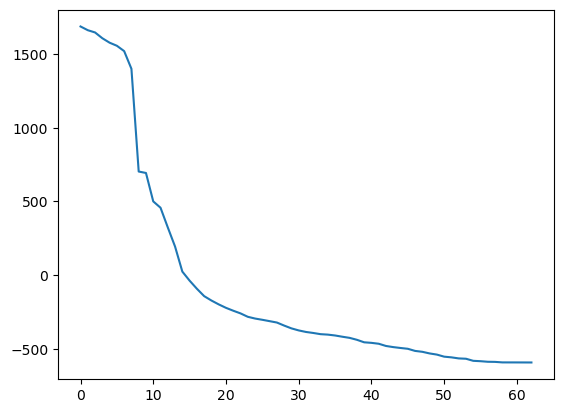

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.56549                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.14492982939356983     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼───────

In [5]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50
print(X)
ivs = np.linspace(min(X[:,0]), max(X[:,0]), nIVS).reshape(-1, 1)
print(ivs)
iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

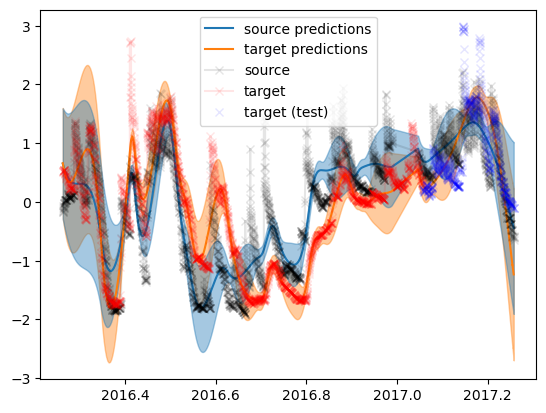

0.2290541324471958

In [6]:
from sklearn.metrics import mean_squared_error
Xtst = Xtest.reshape(-1, 1)
Xall = Ax
Xplot = np.hstack((Xall, np.zeros_like(Xall)))
Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean2, fvar2 = m.predict_f(Xplot2)
fmean_tst, fvar_tst = m.predict_f(Xtest_stack)
plt.plot(Xall, fmean, color="C0", label="source predictions")
plt.plot(Xall, fmean2, color="C1", label="target predictions")
plt.plot(Ax, Ay, "k", marker="x", alpha=0.1, label="source")
plt.plot(Bx, By, "r", marker="x", alpha=0.1, label="target")
plt.plot(Xtest, ytest, "bx", alpha=0.1, label="target (test)")
plt.fill_between(
    Xall[:, 0],
    (fmean2 - 2 * np.sqrt(fvar))[:, 0],
    (fmean2 + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C0",
    alpha=0.4,
)
plt.legend()
#plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()
ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse